In [ ]:
import pandas as pd

df = pd.read_csv("car data.csv")

In [3]:
df.drop_duplicates(inplace=True)

In [4]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
df["Owner"].value_counts()

Owner
0    288
1     10
3      1
Name: count, dtype: int64

In [6]:
df.columns.tolist()

['Car_Name',
 'Year',
 'Selling_Price',
 'Present_Price',
 'Driven_kms',
 'Fuel_Type',
 'Selling_type',
 'Transmission',
 'Owner']

In [7]:
df.shape

(299, 9)

In [8]:
df.dtypes

Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type         object
Selling_type      object
Transmission      object
Owner              int64
dtype: object

In [9]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       299 non-null    object 
 1   Year           299 non-null    int64  
 2   Selling_Price  299 non-null    float64
 3   Present_Price  299 non-null    float64
 4   Driven_kms     299 non-null    int64  
 5   Fuel_Type      299 non-null    object 
 6   Selling_type   299 non-null    object 
 7   Transmission   299 non-null    object 
 8   Owner          299 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 23.4+ KB


In [11]:
df.duplicated().sum()

0

In [12]:
current_year = 2026

df["car_age"] = current_year - df["Year"]

In [13]:
df.drop("Car_Name", axis=1, inplace=True)
df.drop("Year", axis=1, inplace=True)

In [14]:
df.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,car_age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [15]:
df.columns.tolist()

['Selling_Price',
 'Present_Price',
 'Driven_kms',
 'Fuel_Type',
 'Selling_type',
 'Transmission',
 'Owner',
 'car_age']

In [16]:
cat = df.select_dtypes(include="object")
print(cat.columns)

Index(['Fuel_Type', 'Selling_type', 'Transmission'], dtype='object')


In [17]:
num = df.select_dtypes(exclude="object")
print(num.columns)

Index(['Selling_Price', 'Present_Price', 'Driven_kms', 'Owner', 'car_age'], dtype='object')


In [18]:
df.describe()

,Selling_Price,Present_Price,Driven_kms,Owner,car_age
count,299.000000,299.000000,299.000000,299.000000,299.000000
mean,4.589632,7.541037,36916.752508,0.043478,12.384615
std,4.984240,8.566332,39015.170352,0.248720,2.896868
min,0.100000,0.320000,500.000000,0.000000,8.000000
25%,0.850000,1.200000,15000.000000,0.000000,10.000000
50%,3.510000,6.100000,32000.000000,0.000000,12.000000
75%,6.000000,9.840000,48883.500000,0.000000,14.000000
max,35.000000,92.600000,500000.000000,3.000000,23.000000


In [19]:
df["Fuel_Type"].value_counts()

Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

In [20]:
df["Selling_type"].value_counts()

Selling_type
Dealer        193
Individual    106
Name: count, dtype: int64

In [21]:
df["Transmission"].value_counts()

Transmission
Manual       260
Automatic     39
Name: count, dtype: int64

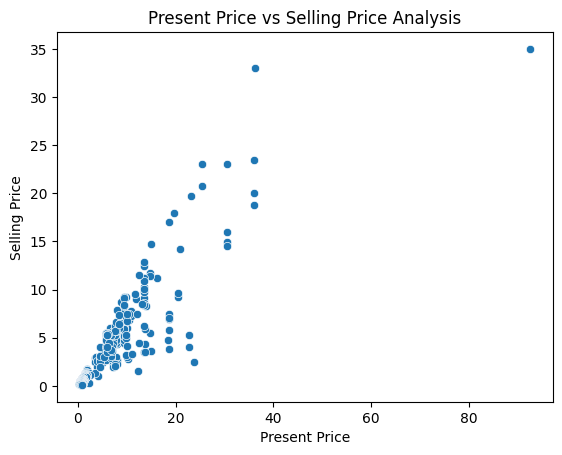

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.scatterplot(data=df, x = "Present_Price", y = "Selling_Price")

plt.title('Present Price vs Selling Price Analysis')
plt.xlabel('Present Price')
plt.ylabel('Selling Price')
plt.show()

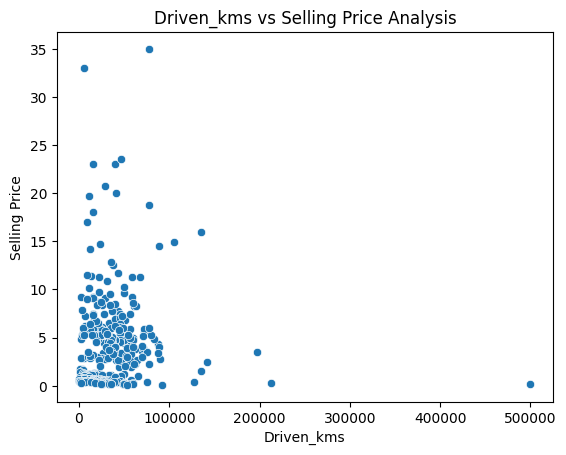

In [23]:
sns.scatterplot(data=df, x = "Driven_kms", y = "Selling_Price")

plt.title('Driven_kms vs Selling Price Analysis')
plt.xlabel('Driven_kms')
plt.ylabel('Selling Price')
plt.show()

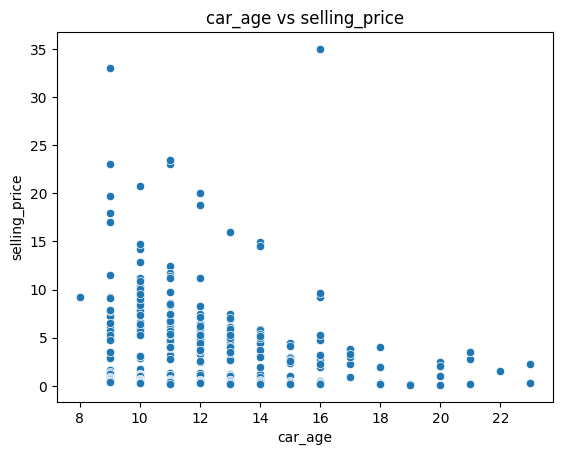

In [24]:
sns.scatterplot(data=df, x="car_age", y="Selling_Price")
plt.title("car_age vs selling_price")
plt.xlabel("car_age")
plt.ylabel("selling_price")
plt.show()

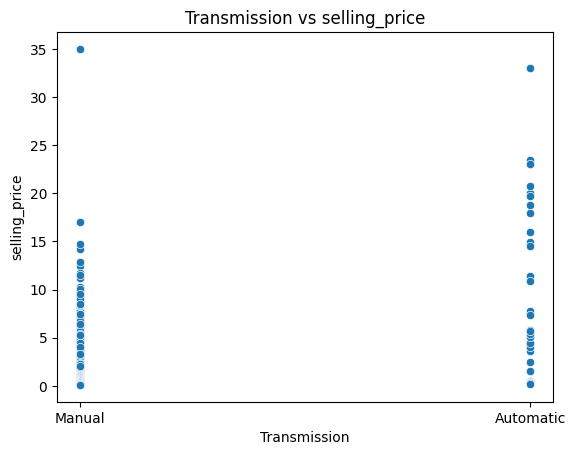

In [25]:
sns.scatterplot(data=df, x="Transmission", y="Selling_Price")
plt.title("Transmission vs selling_price")
plt.xlabel("Transmission")
plt.ylabel("selling_price")
plt.show()

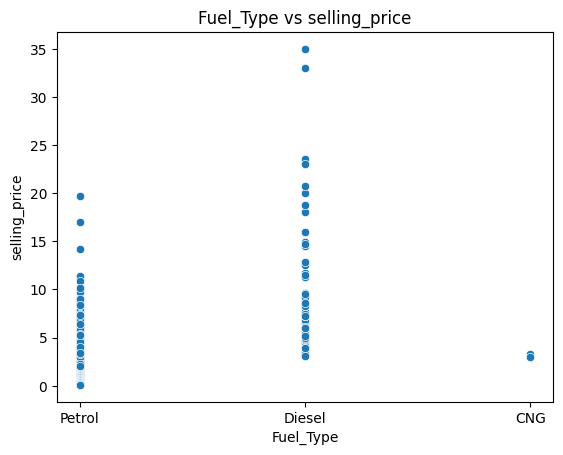

In [26]:
sns.scatterplot(data=df, x="Fuel_Type", y="Selling_Price")
plt.title("Fuel_Type vs selling_price")
plt.xlabel("Fuel_Type")
plt.ylabel("selling_price")
plt.show()

In [27]:
df["Fuel_Type"] = df["Fuel_Type"].map({"Petrol": 0, "Diesel": 1, "CNG": 2})

In [28]:
df["Selling_type"] = df["Selling_type"].map({"Dealer": 0, "Individual": 1})

In [29]:
df["Transmission"] = df["Transmission"].map({"Manual": 0, "Automatic": 1})

In [30]:
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [32]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(239, 7)
(60, 7)
(239,)
(60,)


In [38]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()


model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [39]:
y_pred_lr = model.predict(X_test)

In [40]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score

print(f"MAE : {mean_absolute_error(y_test, y_pred_lr)}")
print(f"MSE : {mean_squared_error(y_test, y_pred_lr)}")
print(f"RMSE : {root_mean_squared_error(y_test, y_pred_lr)}")
print(f"R2 : {r2_score(y_test, y_pred_lr)}")

MAE : 1.5408119549693522
MSE : 6.675444100492251
RMSE : 2.5836880811143303
R2 : 0.7409934356413543


In [41]:
import pandas as pd

comparision_df = pd.DataFrame({
    "Actual" : y_test.values,
    "Predicted" : y_pred_lr
})


print(comparision_df.head())

   Actual  Predicted
0    8.99   7.540145
1    8.35   7.607943
2    0.45   1.360867
3    7.45   6.838162
4    5.25  11.264332


In [42]:
coffe_df = pd.DataFrame({
    "Features" : X_train.columns,
    "Coffesient" : model.coef_
})

print(coffe_df)

        Features  Coffesient
0  Present_Price    0.441254
1     Driven_kms   -0.000009
2      Fuel_Type    1.224948
3   Selling_type   -1.290578
4   Transmission    1.577930
5          Owner    0.698020
6        car_age   -0.342071
